In [ ]:
# === dc5 共通設定（自動挿入: dc5-bootstrap）=======================
# 重み・チェックポイント・データセットの場所は dc5lib が自動で解決する。
# 外部SSDを挿すだけでよく、OS ごとにパスを書き分ける必要はない。
#   weights_path(COND)     → dc5-data/weights/<条件>/best_model.pth
#   checkpoint_path(COND)  → dc5-data/checkpoints/<条件>/model_checkpoint.pth
#   dataset_path(地域, ファイル名) → dc5-data/datasets/<地域>/<ファイル名>
#   curve_path(COND)       → results/curves/<条件>.csv
import sys
from pathlib import Path

for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "dc5lib" / "paths.py").exists():
        sys.path.insert(0, str(_p))
        break
else:
    raise RuntimeError("dc5lib が見つかりません。リポジトリの中で起動してください。")

from dc5lib.paths import weights_path, checkpoint_path, dataset_path, curve_path
from dc5lib.data import load_dataset, dem_dataset, photo_dataset

CONDITION = "AttentionUNet_DEM_APM"
print("条件:", CONDITION)
print("重み:", weights_path(CONDITION))


In [1]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchvision import transforms
from PIL import Image
import pickle
from sklearn.preprocessing import MinMaxScaler
import torch.nn.functional as F
import pandas as pd

In [2]:
import random
import torch
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
# load_any_dataset.py を使うことで、クラス名が違うpkl（広島データ・島根データ）でも
# 同じように読み込めるようにする。
import sys
# sys.path.append(...MakeDataSet)  # dc5lib.data に取り込んだため不要
# from load_any_dataset import ...  # 冒頭の dc5 共通設定セルで読み込み済み

class photo_dataset:
    def __init__(self):
        self.__KeyName = ["No", "DEM", "Mask", "GeoInfo", "EPSG", "Max_H", "Min_H","AirPhoto"]
        self.No = []
        self.DEM = []
        self.Mask = []
        self.GeoInfo = []
        self.EPSG = []
        self.Max_H = []
        self.Min_H = []
        self.AirPhoto=[]

    def key(self):
        return self.__KeyName

path = dataset_path("Hiroshima", "hiroshima_dem_apm_normalized.pkl")
dataset = load_dataset(path)
print(len(dataset.No))
print(dataset.DEM[0].shape)

38148
(128, 128)


In [5]:
print(dataset.GeoInfo[0])

(132.40625, 4.882812499995559e-05, 0.0, 34.025, 0.0, -3.2552082031234164e-05)


In [6]:

dataset2 = photo_dataset()
dataset3 = photo_dataset()
#images2 = []
for i in range(len(dataset.No)):
    if np.max(np.array(dataset.Mask[i])) >= 1:
        dataset2.DEM.append(dataset.DEM[i])
        dataset2.Mask.append(dataset.Mask[i])
        dataset2.No.append(dataset.No[i])
        dataset2.GeoInfo.append(dataset.GeoInfo[i])
        dataset2.EPSG.append(dataset.EPSG[i])
        dataset2.Max_H.append(dataset.Max_H[i])
        dataset2.Min_H.append(dataset.Min_H[i])
        dataset2.AirPhoto.append(dataset.AirPhoto[i])
    else:
        dataset3.DEM.append(dataset.DEM[i])
        dataset3.Mask.append(dataset.Mask[i])
        dataset3.No.append(dataset.No[i])
        dataset3.GeoInfo.append(dataset.GeoInfo[i])
        dataset3.EPSG.append(dataset.EPSG[i])
        dataset3.Max_H.append(dataset.Max_H[i])
        dataset3.Min_H.append(dataset.Min_H[i])
        dataset3.AirPhoto.append(dataset.AirPhoto[i])
        
        #images2.append(images[i])
print(len(dataset2.DEM))
print(len(dataset2.Mask))
print(len(dataset3.DEM))
del dataset

14816
14816
23332


In [7]:
from scipy.ndimage import gaussian_filter
for i in range(len(dataset2.No)):
    dataset2.Mask[i] = np.array(dataset2.Mask[i])
    dataset2.Mask[i] = dataset2.Mask[i].astype(np.uint8) * 255
    dataset2.Mask[i] = gaussian_filter(dataset2.Mask[i], sigma=1)
    dataset2.Mask[i] = (dataset2.Mask[i] > 0).astype(np.uint8)

for i in range(len(dataset3.No)):
    dataset3.Mask[i] = np.array(dataset3.Mask[i])
    dataset3.Mask[i] = dataset3.Mask[i].astype(np.uint8) * 255
    dataset3.Mask[i] = gaussian_filter(dataset3.Mask[i], sigma=1)
    dataset3.Mask[i] = (dataset3.Mask[i] > 0).astype(np.uint8)

In [8]:
import random

random.seed(42)  # 好きな整数

# ============================================================
# 背景タイル（警戒区域を含まないタイル）の追加割合を管理する。
#
# 「配列番号」として dataset2.BgSourceIndex を追加し、各タイルについて
#   - 元々マスクを含むタイルなら None
#   - 背景として追加されたタイルなら dataset3 内での元インデックス
# を記録する。これにより、割合(bg_ratio)を変えて何度も試しても、
# 「今回どのタイルが追加されたか」を後から dataset2.BgSourceIndex で確認できる。
#
# 選択方法は「シャッフル順を固定し、先頭からn_add件を取る」方式にしている。
# そのため、小さい割合で選ばれるタイルは、必ず大きい割合でも選ばれる
# （入れ子構造）。異なる割合の実験結果を、タイルの追加のされ方という
# 観点でも一貫して比較できる。
#
# このセルは何度再実行しても安全（bg_ratioを変えて再実行するたびに、
# 一度「元々のマスクありタイルだけ」の状態に戻してから追加し直すため、
# 重複や蓄積は起きない）。
# ============================================================

if not hasattr(dataset2, "_base_count"):
    # 初回実行時：元々のマスクありタイル数を記録しておく
    dataset2._base_count = len(dataset2.No)
    dataset2.BgSourceIndex = [None] * dataset2._base_count
else:
    # 2回目以降：背景タイルを追加する前の状態（元のマスクありタイルのみ）に戻す
    base_n = dataset2._base_count
    dataset2.DEM = dataset2.DEM[:base_n]
    dataset2.Mask = dataset2.Mask[:base_n]
    dataset2.No = dataset2.No[:base_n]
    dataset2.GeoInfo = dataset2.GeoInfo[:base_n]
    dataset2.EPSG = dataset2.EPSG[:base_n]
    dataset2.Max_H = dataset2.Max_H[:base_n]
    dataset2.Min_H = dataset2.Min_H[:base_n]
    dataset2.AirPhoto = dataset2.AirPhoto[:base_n]
    dataset2.BgSourceIndex = dataset2.BgSourceIndex[:base_n]

# シャッフル順を固定（seedを変えない限り、毎回同じ並び順になる）
bg_order = list(range(len(dataset3.No)))
random.shuffle(bg_order)

# ---- ここを変えて割合を実験する（例: 0.1 なら背景タイルを10%分追加） ----
bg_ratio = 0.0
# --------------------------------------------------------------

n_add = int(len(dataset3.No) * bg_ratio)
selected_indices = bg_order[:n_add]

for i in selected_indices:
    dataset2.DEM.append(dataset3.DEM[i])
    dataset2.Mask.append(dataset3.Mask[i])
    dataset2.No.append(dataset3.No[i])
    dataset2.GeoInfo.append(dataset3.GeoInfo[i])
    dataset2.EPSG.append(dataset3.EPSG[i])
    dataset2.Max_H.append(dataset3.Max_H[i])
    dataset2.Min_H.append(dataset3.Min_H[i])
    dataset2.AirPhoto.append(dataset3.AirPhoto[i])
    dataset2.BgSourceIndex.append(i)  # dataset3内での元インデックスを記録

print("マスクあり元データ数:", dataset2._base_count)
print(f"追加した背景データ数: {n_add} (割合: {bg_ratio*100:.1f}%)")
print("最終データ数:", len(dataset2.No))
print("追加された背景タイルのdataset3内インデックス（先頭10件）:", selected_indices[:10])

# 複数の割合を試す運用を想定し、dataset3は自動では解放しない。
# 全ての割合での実験が終わったら、手動で次を実行してメモリを解放してください：
#   del dataset3; import gc; gc.collect()

マスクあり元データ数: 14816
追加した背景データ数: 0 (割合: 0.0%)
最終データ数: 14816
追加された背景タイルのdataset3内インデックス（先頭10件）: []


In [9]:
# ============================================================
# メモリ節約版:
#  - AirPhoto/Maskはuint8のまま保持し、float化(/255.0含む)は
#    DualInputDatasetの__getitem__内でサンプル単位に行う
#    （float32で全件保持するとAirPhotoだけで4倍のメモリを消費するため）
#  - torch.tensor()ではなくtorch.from_numpy()を使い、余分なコピーを避ける
# ============================================================
dataset2.DEM = np.array(dataset2.DEM, dtype=np.float32)
dataset2.AirPhoto = np.array(dataset2.AirPhoto, dtype=np.uint8)
dataset2.Mask = np.array(dataset2.Mask, dtype=np.uint8)

dataset2.DEM = np.expand_dims(
    dataset2.DEM,
    axis=1)

dataset2.AirPhoto = np.transpose(
    dataset2.AirPhoto,
    (0, 3, 1, 2)
)
# ここでは/255.0しない（uint8のまま持つ。DualInputDataset側で正規化する）

dataset2.Mask = np.expand_dims(
    dataset2.Mask,
    axis=1
)


# tensor化（from_numpyはnumpy配列とメモリを共有するため、コピーが発生しない）
dataset2.DEM = torch.from_numpy(dataset2.DEM)          # float32のまま
dataset2.AirPhoto = torch.from_numpy(dataset2.AirPhoto)  # uint8のまま
dataset2.Mask = torch.from_numpy(dataset2.Mask)          # uint8のまま

In [10]:
# ==========================================
# ⑦ shape確認
# ==========================================
print("AirPhoto shape :", dataset2.AirPhoto.shape)
print("DEM shape  :", dataset2.DEM.shape)
print("Mask shape  :", dataset2.Mask.shape)

# Input : [batch, 2, H, W]
# Mask  : [batch, 1, H, W]

AirPhoto shape : torch.Size([14816, 3, 128, 128])
DEM shape  : torch.Size([14816, 1, 128, 128])
Mask shape  : torch.Size([14816, 1, 128, 128])


In [11]:
from sklearn.model_selection import train_test_split

# まずtestを切り出す（最終評価専用。学習中は一切参照しない）
dem_trainval, dem_test, air_trainval, air_test, y_trainval, y_test, No_trainval, No_test, bg_idx_trainval, bg_idx_test = train_test_split(
    dataset2.DEM,
    dataset2.AirPhoto,
    dataset2.Mask,
    dataset2.No,
    dataset2.BgSourceIndex,
    test_size=0.2,
    random_state=42
)

# 残り(trainval)をtrain/validationに分割する
# （validationは学習中の監視・ベストモデル選択に使う。testはここでは使わない）
dem_train, dem_val, air_train, air_val, y_train, y_val, No_train, No_val, bg_idx_train, bg_idx_val = train_test_split(
    dem_trainval,
    air_trainval,
    y_trainval,
    No_trainval,
    bg_idx_trainval,
    test_size=0.25,  # trainval全体の20%（データ全体で見るとおよそ16%）
    random_state=42
)

n_bg_train = sum(1 for b in bg_idx_train if b is not None)
n_bg_val = sum(1 for b in bg_idx_val if b is not None)
n_bg_test = sum(1 for b in bg_idx_test if b is not None)
print(f"訓練データ数: {len(No_train)} (うち背景タイル: {n_bg_train})")
print(f"検証データ数: {len(No_val)} (うち背景タイル: {n_bg_val})")
print(f"テストデータ数: {len(No_test)} (うち背景タイル: {n_bg_test})")


訓練データ数: 8889 (うち背景タイル: 0)
検証データ数: 2963 (うち背景タイル: 0)
テストデータ数: 2964 (うち背景タイル: 0)


In [12]:
class JointTransform:

    def __init__(
        self,
        rotation_deg=10,
        translate=0.1,
        scale_range=(0.9,1.1),
        hflip=True,
        vflip=True
    ):

        self.rotation_deg = rotation_deg
        self.translate = translate
        self.scale_range = scale_range
        self.hflip = hflip
        self.vflip = vflip

    def __call__(self, dem, air, mask):

        angle = random.uniform(
            -self.rotation_deg,
            self.rotation_deg
        )

        scale = random.uniform(
            self.scale_range[0],
            self.scale_range[1]
        )

        max_dx = int(self.translate * dem.shape[2])
        max_dy = int(self.translate * dem.shape[1])

        translations = (
            random.randint(-max_dx,max_dx),
            random.randint(-max_dy,max_dy)
        )

        if self.hflip and random.random() < 0.5:

            dem = TF.hflip(dem)
            air = TF.hflip(air)
            mask = TF.hflip(mask)

        if self.vflip and random.random() < 0.5:

            dem = TF.vflip(dem)
            air = TF.vflip(air)
            mask = TF.vflip(mask)

        dem = TF.affine(
            dem,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=0,
            interpolation=TF.InterpolationMode.BILINEAR
        )

        air = TF.affine(
            air,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=0,
            interpolation=TF.InterpolationMode.BILINEAR
        )

        mask = TF.affine(
            mask,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=0,
            interpolation=TF.InterpolationMode.NEAREST
        )

        return dem, air, mask

In [13]:
class DualInputDataset(Dataset):

    def __init__(
        self,
        dem_images,
        air_images,
        masks,
        transform=None
    ):

        self.dem_images = dem_images
        self.air_images = air_images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.masks)

    def __getitem__(self, idx):

        # DEMは元からfloat32。AirPhoto/Maskはuint8で保持しているので
        # ここでサンプル単位にfloat化する（メモリ節約のため）
        dem = self.dem_images[idx].float()
        air = self.air_images[idx].float() / 255.0
        mask = self.masks[idx].float()

        if self.transform:

            dem, air, mask = self.transform(
                dem,
                air,
                mask
            )

        return (dem, air), mask

In [14]:
joint_transform = JointTransform(
    rotation_deg=15,
    translate=0.1,
    scale_range=(0.8,1.2),
    hflip=True,
    vflip=True
)

train_dataset = DualInputDataset(
    dem_train,
    air_train,
    y_train
    #joint_transform
)

val_dataset = DualInputDataset(
    dem_val,
    air_val,
    y_val
)

test_dataset = DualInputDataset(
    dem_test,
    air_test,
    y_test
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)
test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [15]:
def dice_loss(pred, target, smooth = 1.):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=2).sum(dim=2)
    loss = (1 - ((2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)))
    return loss.mean()


lambda_l1 = 1e-5
lambda_l2 = 1e-5

def elastic_net_regularization(model):
    l1_norm = sum(p.abs().sum() for p in model.parameters())
    l2_norm = sum((p ** 2).sum() for p in model.parameters())
    return lambda_l1 * l1_norm + lambda_l2 * l2_norm


def calc_loss(pred, target, metrics=None, bce_weight=0.5):
    # Dice LossとCategorical Cross Entropyを混ぜていい感じにしている
    bce = F.binary_cross_entropy_with_logits(pred, target)
    pred = torch.sigmoid(pred)
    dice = dice_loss(pred, target)
    loss = bce * bce_weight + dice * (1 - bce_weight)
    return loss

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.8, beta=0.2, gamma=0.75, smooth=1e-6):
        """
        alpha: False negative penalty
        beta: False positive penalty
        gamma: Focal parameter
        smooth: Avoid division by zero
        """
        super(FocalTverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, preds, targets):
        """
        preds: Predicted probabilities (N, C, H, W) or (N, 1, H, W)
        targets: Ground truth labels (N, C, H, W) or (N, 1, H, W)
        """
        #preds = torch.sigmoid(preds)  # 確率に変換
        preds = torch.sigmoid(preds.clamp(-10, 10))

        # Flatten tensors
        preds = preds.view(preds.size(0), -1)        
        targets = targets.view(targets.size(0), -1)

        TP = (preds * targets).sum(1)
        FP = ((1 - targets) * preds).sum(1)
        FN = (targets * (1 - preds)).sum(1)

        tversky = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
         # 数値安定化: tverskyの範囲を [0,1] に保つ
        tversky = torch.clamp(tversky, min=self.smooth, max=1.0)
        focal_tversky = torch.pow((1 - tversky), self.gamma)

        return focal_tversky.mean()

criterion = FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=0.75)
def calc_loss(pred, target):
    loss = criterion(pred, target)
    return loss

In [17]:
import torch
import torch.nn as nn


class MultiEncoderUNet(nn.Module):

    def __init__(self, out_channels=1):
        super(MultiEncoderUNet, self).__init__()


        # ===== Slope Encoder =====
        self.slope_enc1 = self.conv_block(1, 64)
        self.slope_pool1 = nn.MaxPool2d(2)

        self.slope_enc2 = self.conv_block(64, 128)
        self.slope_pool2 = nn.MaxPool2d(2)

        self.slope_enc3 = self.conv_block(128, 256)
        self.slope_pool3 = nn.MaxPool2d(2)

        self.slope_enc4 = self.conv_block(256, 512)
        self.slope_pool4 = nn.MaxPool2d(2)

        # ===== Curvature Encoder =====
        self.curv_enc1 = self.conv_block(3, 64)
        self.curv_pool1 = nn.MaxPool2d(2)

        self.curv_enc2 = self.conv_block(64, 128)
        self.curv_pool2 = nn.MaxPool2d(2)

        self.curv_enc3 = self.conv_block(128, 256)
        self.curv_pool3 = nn.MaxPool2d(2)

        self.curv_enc4 = self.conv_block(256, 512)
        self.curv_pool4 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout(0.25)

        # ===== Bottleneck =====
        # 512 × 2 = 1536 channels
        self.bottleneck = self.conv_block(1024, 1024)
        self.dropout = nn.Dropout(0.5)

        # ===== Decoder =====
        self.up4 = nn.ConvTranspose2d(
            1024, 512,
            kernel_size=2,
            stride=2
        )
        #したの512のかける係数はマルチに用いるチャネル数（今回は2)#
        self.dec4 = self.conv_block(
            512 + 512*2,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512, 256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = self.conv_block(
            256 + 256*2,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256, 128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = self.conv_block(
            128 + 128*2,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = self.conv_block(
            64 + 64*2,
            64
        )

        # Output
        self.out_conv = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def conv_block(self, in_ch, out_ch):

        return nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_ch,
                out_ch,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self,dem,air):

        # =========================
        # 入力分離
        # =========================

        
        
        

        # =========================
        # Slope Encoder
        # =========================

        slope1 = self.slope_enc1(dem)
        slope2 = self.slope_enc2(self.slope_pool1(slope1))
        slope3 = self.slope_enc3(self.slope_pool2(slope2))
        slope4 = self.slope_enc4(self.slope_pool3(slope3))
        slope4 = self.dropout2(slope4)

        # =========================
        # Curvature Encoder
        # =========================

        curv1 = self.curv_enc1(air)
        curv2 = self.curv_enc2(self.curv_pool1(curv1))
        curv3 = self.curv_enc3(self.curv_pool2(curv2))
        curv4 = self.curv_enc4(self.curv_pool3(curv3))
        curv4 = self.dropout2(curv4)

        # =========================
        # Bottleneck fusion
        # =========================

        fused = torch.cat(
            [
                self.slope_pool4(slope4),
                self.curv_pool4(curv4)
            ],
            dim=1
        )

        bottleneck = self.bottleneck(fused)
        bottleneck = self.dropout(bottleneck)

        # =========================
        # Decoder
        # =========================

        up4 = self.up4(bottleneck)

        skip4 = torch.cat(
            [slope4, curv4],
            dim=1
        )
        dec4 = self.dec4(
            torch.cat([up4, skip4], dim=1)
        )

        up3 = self.up3(dec4)

        skip3 = torch.cat(
            [slope3, curv3],
            dim=1
        )

        dec3 = self.dec3(
            torch.cat([up3, skip3], dim=1)
        )

        up2 = self.up2(dec3)

        skip2 = torch.cat(
            [slope2, curv2],
            dim=1
        )

        dec2 = self.dec2(
            torch.cat([up2, skip2], dim=1)
        )

        up1 = self.up1(dec2)

        skip1 = torch.cat(
            [slope1, curv1],
            dim=1
        )

        dec1 = self.dec1(
            torch.cat([up1, skip1], dim=1)
        )

        return self.out_conv(dec1)

### 融合方式（Early / Middle / Late Fusion）について

マルチモーダルなセマンティックセグメンテーションの融合方式は、文献では主に3種類に分類される
（[Deep multimodal fusion for semantic image segmentation: A survey](https://arxiv.org/pdf/2303.15777) 等）。

- **Early Fusion（データレベル融合）**: 入力の時点で複数モダリティをチャネル結合し、単一のエンコーダで処理する。
  実装がシンプルでパラメータ数も少ないが、モダリティ固有の特徴抽出ができない。
- **Late Fusion（決定/特徴レベル融合、現在の`MultiEncoderUNet`）**: モダリティごとに独立したエンコーダで
  最後まで処理し、ボトルネックやスキップ接続の時点で結合する。モダリティ固有の特徴を保てるが、
  浅い層でのモダリティ間の相互作用が起きない。
- **Middle Fusion（中間融合）**: 独立したエンコーダを持ちつつ、各ステージごとに特徴を融合し、
  その情報を両ストリームに伝播させてから次のステージに進む。近年の文献では、早期・後期融合単体より
  性能が良いと報告されることが多い（RGB-D等での報告例: [DCANet](https://arxiv.org/pdf/2210.06747)）。

以下に`EarlyFusionUNet`・`MiddleFusionUNet`を追加した。呼び出し方法（`model(dem, air)`）は
既存の`MultiEncoderUNet`と統一してあるので、後段のモデルインスタンス化セルでクラス名を
変更するだけで切り替えられる。

In [18]:
import torch
import torch.nn as nn


def _shared_conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


# ============================================================
# Early Fusion U-Net
#   入力段階でDEM(1ch)とAirPhoto(3ch)をチャネル結合(4ch)し、
#   単一の共有エンコーダで処理する。
# ============================================================
class EarlyFusionUNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()
        in_ch = 1 + 3  # DEM + AirPhoto

        self.enc1 = _shared_conv_block(in_ch, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = _shared_conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = _shared_conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = _shared_conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout(0.25)

        self.bottleneck = _shared_conv_block(512, 1024)
        self.dropout = nn.Dropout(0.5)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = _shared_conv_block(512 + 512, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = _shared_conv_block(256 + 256, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = _shared_conv_block(128 + 128, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = _shared_conv_block(64 + 64, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, dem, air):
        x = torch.cat([dem, air], dim=1)  # ここでearly fusion（チャネル結合）

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        e4 = self.dropout2(e4)

        b = self.bottleneck(self.pool4(e4))
        b = self.dropout(b)

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_conv(d1)

In [19]:
# ============================================================
# Middle Fusion U-Net
#   DEM/AirPhotoそれぞれ独立したエンコーダを持つが、各ステージの後で
#   特徴を一度融合し（concat+1x1conv）、その融合結果を両方のストリームに
#   残差的に加算してから次のステージに進む。これにより、エンコーダの
#   浅い段階から両モダリティの情報が互いに伝わるようになる。
# ============================================================
class FusionGate(nn.Module):
    """2つのモダリティの特徴を融合し、同じチャネル数で返す（残差加算用）"""
    def __init__(self, ch):
        super().__init__()
        self.fuse = nn.Sequential(
            nn.Conv2d(ch * 2, ch, kernel_size=1),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, a, b):
        return self.fuse(torch.cat([a, b], dim=1))


class MiddleFusionUNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()

        self.slope_enc1 = _shared_conv_block(1, 64)
        self.curv_enc1 = _shared_conv_block(3, 64)
        self.fuse1 = FusionGate(64)
        self.pool1 = nn.MaxPool2d(2)

        self.slope_enc2 = _shared_conv_block(64, 128)
        self.curv_enc2 = _shared_conv_block(64, 128)
        self.fuse2 = FusionGate(128)
        self.pool2 = nn.MaxPool2d(2)

        self.slope_enc3 = _shared_conv_block(128, 256)
        self.curv_enc3 = _shared_conv_block(128, 256)
        self.fuse3 = FusionGate(256)
        self.pool3 = nn.MaxPool2d(2)

        self.slope_enc4 = _shared_conv_block(256, 512)
        self.curv_enc4 = _shared_conv_block(256, 512)
        self.fuse4 = FusionGate(512)
        self.pool4 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout(0.25)

        # ボトルネックは、融合済みの2ストリームをconcatして処理（Late版と同じ1024ch）
        self.bottleneck = _shared_conv_block(1024, 1024)
        self.dropout = nn.Dropout(0.5)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = _shared_conv_block(512 + 512 * 2, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = _shared_conv_block(256 + 256 * 2, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = _shared_conv_block(128 + 128 * 2, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = _shared_conv_block(64 + 64 * 2, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def _stage(self, slope_in, curv_in, slope_enc, curv_enc, fuse_gate):
        s = slope_enc(slope_in)
        c = curv_enc(curv_in)
        fused = fuse_gate(s, c)
        # 融合結果を両ストリームに残差加算し、次のステージへの入力にする
        s_out = s + fused
        c_out = c + fused
        return s_out, c_out  # skip connectionにはs_out/c_outを使う（融合情報を含む）

    def forward(self, dem, air):
        slope1, curv1 = self._stage(dem, air, self.slope_enc1, self.curv_enc1, self.fuse1)
        slope2, curv2 = self._stage(self.pool1(slope1), self.pool1(curv1), self.slope_enc2, self.curv_enc2, self.fuse2)
        slope3, curv3 = self._stage(self.pool2(slope2), self.pool2(curv2), self.slope_enc3, self.curv_enc3, self.fuse3)
        slope4, curv4 = self._stage(self.pool3(slope3), self.pool3(curv3), self.slope_enc4, self.curv_enc4, self.fuse4)
        slope4 = self.dropout2(slope4)
        curv4 = self.dropout2(curv4)

        fused_bottom = torch.cat([self.pool4(slope4), self.pool4(curv4)], dim=1)
        b = self.bottleneck(fused_bottom)
        b = self.dropout(b)

        d4 = self.dec4(torch.cat([self.up4(b), slope4, curv4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), slope3, curv3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), slope2, curv2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), slope1, curv1], dim=1))

        return self.out_conv(d1)

In [20]:
# 3種類の融合方式のパラメータ数・出力shapeを確認（動作検証も兼ねる）
_dem_dummy = torch.randn(2, 1, 128, 128)
_air_dummy = torch.randn(2, 3, 128, 128)

for _name, _cls in [
    ("EarlyFusionUNet", EarlyFusionUNet),
    ("MiddleFusionUNet", MiddleFusionUNet),
    ("MultiEncoderUNet (Late Fusion, 既存)", MultiEncoderUNet),
]:
    _m = _cls()
    _out = _m(_dem_dummy, _air_dummy)
    _n_params = sum(p.numel() for p in _m.parameters())
    print(f"{_name}: 出力shape={tuple(_out.shape)}  パラメータ数={_n_params:,}")

EarlyFusionUNet: 出力shape=(2, 1, 128, 128)  パラメータ数=31,044,097
MiddleFusionUNet: 出力shape=(2, 1, 128, 128)  パラメータ数=44,282,817
MultiEncoderUNet (Late Fusion, 既存): 出力shape=(2, 1, 128, 128)  パラメータ数=43,583,617


### Attention U-Net / TransUNet について

- **Attention U-Net**（[Oktay et al. 2018](https://smcdonagh.github.io/papers/attention_u_net_learning_where_to_look_for_the_pancreas.pdf)）:
  スキップ接続に「Attention Gate」を追加したモデル。デコーダ側の特徴（ゲート信号 g）を使って、
  エンコーダ側のスキップ接続 x のどの空間位置が重要かを0〜1の係数で判定し、
  重要でない領域（背景など）を抑制してからデコーダに結合する。追加パラメータは少なく、
  既存のLate Fusion構造（独立2エンコーダ）にそのまま組み込める。
- **TransUNet**（[Chen et al. 2021](https://arxiv.org/abs/2102.04306)）:
  CNNエンコーダ＋Transformerボトルネック＋CNNデコーダのハイブリッド構造。
  CNNで局所的な特徴を抽出した後、ボトルネックの特徴マップ（今回は128x128入力→
  4回プーリングで8x8=64トークン）をSelf-Attentionで処理し、画像全体にわたる
  大域的な文脈を捉えてからCNNデコーダで復元する。パラメータ数は大きく増える。

どちらも呼び出し方法は`model(dem, air)`で統一してあるので、既存モデルと同様に
`ModelClass`を切り替えるだけで使える。

In [21]:
import torch
import torch.nn as nn


# ============================================================
# Attention Gate (Oktay et al. 2018)
#   g: デコーダ側のゲート信号（粗い解像度、深い層）
#   x: エンコーダ側のスキップ接続（細かい解像度）
#   x に対する空間的な注意係数(0-1)を計算し、x に掛けて返す
# ============================================================
class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, kernel_size=1),
            nn.BatchNorm2d(inter_ch),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, kernel_size=1),
            nn.BatchNorm2d(inter_ch),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


# ============================================================
# Attention U-Net (デュアル入力: DEM/SAM + AirPhoto)
#   既存のLate Fusion構造（独立2エンコーダ）をベースに、デコーダで
#   スキップ接続を結合する前に、各モダリティそれぞれにAttention Gateをかける。
# ============================================================
class AttentionMultiEncoderUNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()

        self.slope_enc1 = _shared_conv_block(1, 64)
        self.slope_pool1 = nn.MaxPool2d(2)
        self.slope_enc2 = _shared_conv_block(64, 128)
        self.slope_pool2 = nn.MaxPool2d(2)
        self.slope_enc3 = _shared_conv_block(128, 256)
        self.slope_pool3 = nn.MaxPool2d(2)
        self.slope_enc4 = _shared_conv_block(256, 512)
        self.slope_pool4 = nn.MaxPool2d(2)

        self.curv_enc1 = _shared_conv_block(3, 64)
        self.curv_pool1 = nn.MaxPool2d(2)
        self.curv_enc2 = _shared_conv_block(64, 128)
        self.curv_pool2 = nn.MaxPool2d(2)
        self.curv_enc3 = _shared_conv_block(128, 256)
        self.curv_pool3 = nn.MaxPool2d(2)
        self.curv_enc4 = _shared_conv_block(256, 512)
        self.curv_pool4 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout(0.25)

        self.bottleneck = _shared_conv_block(1024, 1024)
        self.dropout = nn.Dropout(0.5)

        self.ag4_slope = AttentionGate(gate_ch=512, skip_ch=512, inter_ch=256)
        self.ag4_curv = AttentionGate(gate_ch=512, skip_ch=512, inter_ch=256)
        self.ag3_slope = AttentionGate(gate_ch=256, skip_ch=256, inter_ch=128)
        self.ag3_curv = AttentionGate(gate_ch=256, skip_ch=256, inter_ch=128)
        self.ag2_slope = AttentionGate(gate_ch=128, skip_ch=128, inter_ch=64)
        self.ag2_curv = AttentionGate(gate_ch=128, skip_ch=128, inter_ch=64)
        self.ag1_slope = AttentionGate(gate_ch=64, skip_ch=64, inter_ch=32)
        self.ag1_curv = AttentionGate(gate_ch=64, skip_ch=64, inter_ch=32)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = _shared_conv_block(512 + 512 * 2, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = _shared_conv_block(256 + 256 * 2, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = _shared_conv_block(128 + 128 * 2, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = _shared_conv_block(64 + 64 * 2, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, dem, air):
        slope1 = self.slope_enc1(dem)
        slope2 = self.slope_enc2(self.slope_pool1(slope1))
        slope3 = self.slope_enc3(self.slope_pool2(slope2))
        slope4 = self.slope_enc4(self.slope_pool3(slope3))
        slope4 = self.dropout2(slope4)

        curv1 = self.curv_enc1(air)
        curv2 = self.curv_enc2(self.curv_pool1(curv1))
        curv3 = self.curv_enc3(self.curv_pool2(curv2))
        curv4 = self.curv_enc4(self.curv_pool3(curv3))
        curv4 = self.dropout2(curv4)

        fused = torch.cat([self.slope_pool4(slope4), self.curv_pool4(curv4)], dim=1)
        b = self.bottleneck(fused)
        b = self.dropout(b)

        up4 = self.up4(b)
        slope4_att = self.ag4_slope(up4, slope4)
        curv4_att = self.ag4_curv(up4, curv4)
        dec4 = self.dec4(torch.cat([up4, slope4_att, curv4_att], dim=1))

        up3 = self.up3(dec4)
        slope3_att = self.ag3_slope(up3, slope3)
        curv3_att = self.ag3_curv(up3, curv3)
        dec3 = self.dec3(torch.cat([up3, slope3_att, curv3_att], dim=1))

        up2 = self.up2(dec3)
        slope2_att = self.ag2_slope(up2, slope2)
        curv2_att = self.ag2_curv(up2, curv2)
        dec2 = self.dec2(torch.cat([up2, slope2_att, curv2_att], dim=1))

        up1 = self.up1(dec2)
        slope1_att = self.ag1_slope(up1, slope1)
        curv1_att = self.ag1_curv(up1, curv1)
        dec1 = self.dec1(torch.cat([up1, slope1_att, curv1_att], dim=1))

        return self.out_conv(dec1)

In [22]:
# ============================================================
# Transformer Bottleneck（TransUNet流）
# ============================================================
class TransformerBottleneck(nn.Module):
    def __init__(self, dim, num_heads=8, num_layers=4, mlp_ratio=4, spatial_size=8):
        super().__init__()
        num_tokens = spatial_size * spatial_size
        self.pos_embed = nn.Parameter(torch.zeros(1, num_tokens, dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=num_heads,
            dim_feedforward=dim * mlp_ratio,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        B, C, H, W = x.shape
        tokens = x.flatten(2).transpose(1, 2)  # B, H*W, C
        tokens = tokens + self.pos_embed
        tokens = self.transformer(tokens)
        return tokens.transpose(1, 2).reshape(B, C, H, W)


# ============================================================
# TransUNet (デュアル入力版)
#   CNNエンコーダ(既存のLate Fusion構造)＋Transformerボトルネック＋CNNデコーダ
# ============================================================
class TransUNetDual(nn.Module):
    def __init__(self, out_channels=1, num_heads=8, num_transformer_layers=4, input_size=128):
        super().__init__()

        self.slope_enc1 = _shared_conv_block(1, 64)
        self.slope_pool1 = nn.MaxPool2d(2)
        self.slope_enc2 = _shared_conv_block(64, 128)
        self.slope_pool2 = nn.MaxPool2d(2)
        self.slope_enc3 = _shared_conv_block(128, 256)
        self.slope_pool3 = nn.MaxPool2d(2)
        self.slope_enc4 = _shared_conv_block(256, 512)
        self.slope_pool4 = nn.MaxPool2d(2)

        self.curv_enc1 = _shared_conv_block(3, 64)
        self.curv_pool1 = nn.MaxPool2d(2)
        self.curv_enc2 = _shared_conv_block(64, 128)
        self.curv_pool2 = nn.MaxPool2d(2)
        self.curv_enc3 = _shared_conv_block(128, 256)
        self.curv_pool3 = nn.MaxPool2d(2)
        self.curv_enc4 = _shared_conv_block(256, 512)
        self.curv_pool4 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout(0.25)

        self.bottleneck_conv = _shared_conv_block(1024, 1024)
        spatial_size = input_size // 16
        self.transformer = TransformerBottleneck(
            dim=1024, num_heads=num_heads, num_layers=num_transformer_layers, spatial_size=spatial_size
        )
        self.dropout = nn.Dropout(0.5)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = _shared_conv_block(512 + 512 * 2, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = _shared_conv_block(256 + 256 * 2, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = _shared_conv_block(128 + 128 * 2, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = _shared_conv_block(64 + 64 * 2, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, dem, air):
        slope1 = self.slope_enc1(dem)
        slope2 = self.slope_enc2(self.slope_pool1(slope1))
        slope3 = self.slope_enc3(self.slope_pool2(slope2))
        slope4 = self.slope_enc4(self.slope_pool3(slope3))
        slope4 = self.dropout2(slope4)

        curv1 = self.curv_enc1(air)
        curv2 = self.curv_enc2(self.curv_pool1(curv1))
        curv3 = self.curv_enc3(self.curv_pool2(curv2))
        curv4 = self.curv_enc4(self.curv_pool3(curv3))
        curv4 = self.dropout2(curv4)

        fused = torch.cat([self.slope_pool4(slope4), self.curv_pool4(curv4)], dim=1)
        b = self.bottleneck_conv(fused)
        b = self.transformer(b)
        b = self.dropout(b)

        up4 = self.up4(b)
        dec4 = self.dec4(torch.cat([up4, slope4, curv4], dim=1))
        up3 = self.up3(dec4)
        dec3 = self.dec3(torch.cat([up3, slope3, curv3], dim=1))
        up2 = self.up2(dec3)
        dec2 = self.dec2(torch.cat([up2, slope2, curv2], dim=1))
        up1 = self.up1(dec2)
        dec1 = self.dec1(torch.cat([up1, slope1, curv1], dim=1))

        return self.out_conv(dec1)

In [23]:
# Attention U-Net / TransUNet の動作検証（順伝播・逆伝播）
_dem_dummy2 = torch.randn(2, 1, 128, 128)
_air_dummy2 = torch.randn(2, 3, 128, 128)
_target_dummy = torch.randint(0, 2, (2, 1, 128, 128)).float()

for _name, _cls in [
    ("AttentionMultiEncoderUNet", AttentionMultiEncoderUNet),
    ("TransUNetDual", TransUNetDual),
]:
    _m = _cls()
    _out = _m(_dem_dummy2, _air_dummy2)
    _n_params = sum(p.numel() for p in _m.parameters())
    _loss = nn.functional.binary_cross_entropy_with_logits(_out, _target_dummy)
    _loss.backward()
    print(f"{_name}: 出力shape={tuple(_out.shape)}  パラメータ数={_n_params:,}  逆伝播OK")

AttentionMultiEncoderUNet: 出力shape=(2, 1, 128, 128)  パラメータ数=44,286,681  逆伝播OK
TransUNetDual: 出力shape=(2, 1, 128, 128)  パラメータ数=94,034,049  逆伝播OK


In [24]:
# ---- ここで使うモデルを選ぶ ----
# MultiEncoderUNet          : Late Fusion（既存、モダリティごとに独立エンコーダ、終盤で結合）
# EarlyFusionUNet           : Early Fusion（入力段階でチャネル結合し単一エンコーダ）
# MiddleFusionUNet          : Middle Fusion（独立エンコーダ＋各ステージで融合・残差伝播）
# AttentionMultiEncoderUNet : Late Fusion + Attention Gate（スキップ接続で注意機構）
# TransUNetDual             : CNNエンコーダ + Transformerボトルネック + CNNデコーダ
ModelClass = AttentionMultiEncoderUNet
# --------------------------------

# モデル、損失関数、オプティマイザをインスタンス化
model = ModelClass(
    out_channels=1
)

# 損失関数とオプティマイザ
loss_fn = calc_loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# GPUがサポートされている場合
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"使用モデル: {ModelClass.__name__}")
print(model)

使用モデル: AttentionMultiEncoderUNet
AttentionMultiEncoderUNet(
  (slope_enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (slope_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (slope_enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (slope_poo

In [25]:
print(device)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

cuda
True
1


In [26]:
losses = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
test_f1_scores = []
best_f1_score = 0.0


In [26]:
print("losses", len(losses))
print("accuracies", len(accuracies))
print("precisions", len(precisions))
print("recalls", len(recalls))
print("f1_scores", len(f1_scores))
print("test_f1_scores", len(test_f1_scores))

losses 0
accuracies 0
precisions 0
recalls 0
f1_scores 0
test_f1_scores 0


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gc
from tqdm import tqdm

# 保存するエポック間隔を設定（例えば10エポックごと）
save_interval = 10
print_interval = 10
save_path = checkpoint_path(CONDITION)
losses_csv_path = curve_path(CONDITION)

# ============================================================
# 学習の途中から再開する場合の初期化
# ※ train/val/testの3分割に変更したため、以前(test_loaderで監視していた頃)の
#   losses.csv・model_checkpoint.pth とは列構成が異なる。古いファイルが
#   残っている場合は削除してから、このセルを最初から実行してください。
# ============================================================
start_epoch = 0
losses, accuracies, precisions, recalls, f1_scores, val_f1_scores = [], [], [], [], [], []
best_f1_score = 0.0

if os.path.exists(save_path):
    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    print(f"Checkpoint loaded! Resuming from epoch {start_epoch + 1}")

    if os.path.exists(losses_csv_path):
        history_df = pd.read_csv(losses_csv_path)
        history_df = history_df[history_df["Epoch"] <= start_epoch]
        losses = history_df["Loss"].tolist()
        accuracies = history_df["Accuracy"].tolist()
        precisions = history_df["Precision"].tolist()
        recalls = history_df["Recall"].tolist()
        f1_scores = history_df["F1-score"].tolist()
        val_f1_scores = history_df["Validation-F1-score"].tolist()
        best_f1_score = max(val_f1_scores) if val_f1_scores else 0.0
        print(f"losses.csv から {len(losses)} エポック分の履歴を復元しました（best val F1: {best_f1_score:.4f}）")
    else:
        print("losses.csv が見つからないため、履歴は空の状態から再開します")

# Training loop
num_epochs = 1000
for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    tp_sum = 0
    fp_sum = 0
    fn_sum = 0

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)

    for (dem,air), masks in train_loader_tqdm:
        dem=dem.to(device)
        air=air.to(device)
        masks=masks.to(device)

        optimizer.zero_grad()

        outputs = model(dem,air)
        loss = loss_fn(outputs, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()

        correct_preds += (preds == masks).sum().item()
        total_preds += masks.numel()

        preds_bin = (preds > 0.5)
        targets_bin = (masks > 0.5)
        tp_sum += ((preds_bin) & (targets_bin)).sum().item()
        fp_sum += ((preds_bin) & (~targets_bin)).sum().item()
        fn_sum += ((~preds_bin) & (targets_bin)).sum().item()

        train_loader_tqdm.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_loader)
    avg_accuracy = correct_preds / total_preds

    precision = tp_sum / (tp_sum + fp_sum) if (tp_sum + fp_sum) > 0 else 0.0
    recall = tp_sum / (tp_sum + fn_sum) if (tp_sum + fn_sum) > 0 else 0.0
    f1 = (2 * tp_sum) / (2 * tp_sum + fp_sum + fn_sum) if (2 * tp_sum + fp_sum + fn_sum) > 0 else 0.0

    losses.append(avg_loss)
    accuracies.append(avg_accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    # 検証データで評価（学習中の監視・ベストモデル選択用。testはここでは使わない）
    model.eval()
    val_tp_sum = 0
    val_fp_sum = 0
    val_fn_sum = 0
    with torch.no_grad():
        for (dem,air), masks in tqdm(val_loader, desc="Validating", leave=False):
            dem=dem.to(device)
            air=air.to(device)
            masks=masks.to(device)

            outputs = model(dem,air)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            preds_bin = (preds > 0.5)
            targets_bin = (masks > 0.5)
            val_tp_sum += ((preds_bin) & (targets_bin)).sum().item()
            val_fp_sum += ((preds_bin) & (~targets_bin)).sum().item()
            val_fn_sum += ((~preds_bin) & (targets_bin)).sum().item()

    val_f1 = (2 * val_tp_sum) / (2 * val_tp_sum + val_fp_sum + val_fn_sum) if (2 * val_tp_sum + val_fp_sum + val_fn_sum) > 0 else 0.0
    val_f1_scores.append(val_f1)

    if val_f1 > best_f1_score:
        best_f1_score = val_f1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'best_f1_score': best_f1_score
        }, weights_path(CONDITION))
        print(f"Best model saved at epoch {epoch+1} with Validation F1-score: {val_f1:.4f}")

    if (epoch + 1) % save_interval == 0:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'best_f1_score': best_f1_score
        }
        torch.save(checkpoint, save_path)
        df = pd.DataFrame({
            "Epoch": list(range(1, len(losses) + 1)),
            "Loss": losses,
            "Accuracy": accuracies,
            "Precision": precisions,
            "Recall": recalls,
            "F1-score": f1_scores,
            "Validation-F1-score" : val_f1_scores
        })
        df.to_csv(losses_csv_path, index=False, encoding="utf-8")
        print(f"Checkpoint saved at epoch {epoch + 1}")

    if (epoch + 1) % print_interval == 0 or epoch == start_epoch:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {avg_accuracy:.4f}, "
              f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, Val-F1: {val_f1:.4f}")
    else:
        print(f"Epoch [{epoch+1}/{num_epochs}] val f1: {val_f1:.4f}")

    del outputs, preds, preds_bin, targets_bin, dem, air, masks
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Best model saved at epoch 1 with Validation F1-score: 0.4703
Epoch [1/1000], Loss: 0.7190, Accuracy: 0.7252, Precision: 0.2378, Recall: 0.8864, F1-score: 0.3749, Val-F1: 0.4703


Epoch [2/1000] val f1: 0.4631


Best model saved at epoch 3 with Validation F1-score: 0.5613
Epoch [3/1000] val f1: 0.5613


Best model saved at epoch 4 with Validation F1-score: 0.5760
Epoch [4/1000] val f1: 0.5760


Best model saved at epoch 5 with Validation F1-score: 0.6003
Epoch [5/1000] val f1: 0.6003


...

Epoch [996/1000] val f1: 0.6407


Epoch [997/1000] val f1: 0.6419


Epoch [998/1000] val f1: 0.6429


Epoch [999/1000] val f1: 0.6408


Checkpoint saved at epoch 1000
Epoch [1000/1000], Loss: 0.0590, Accuracy: 0.9962, Precision: 0.9794, Recall: 0.9797, F1-score: 0.9796, Val-F1: 0.6484


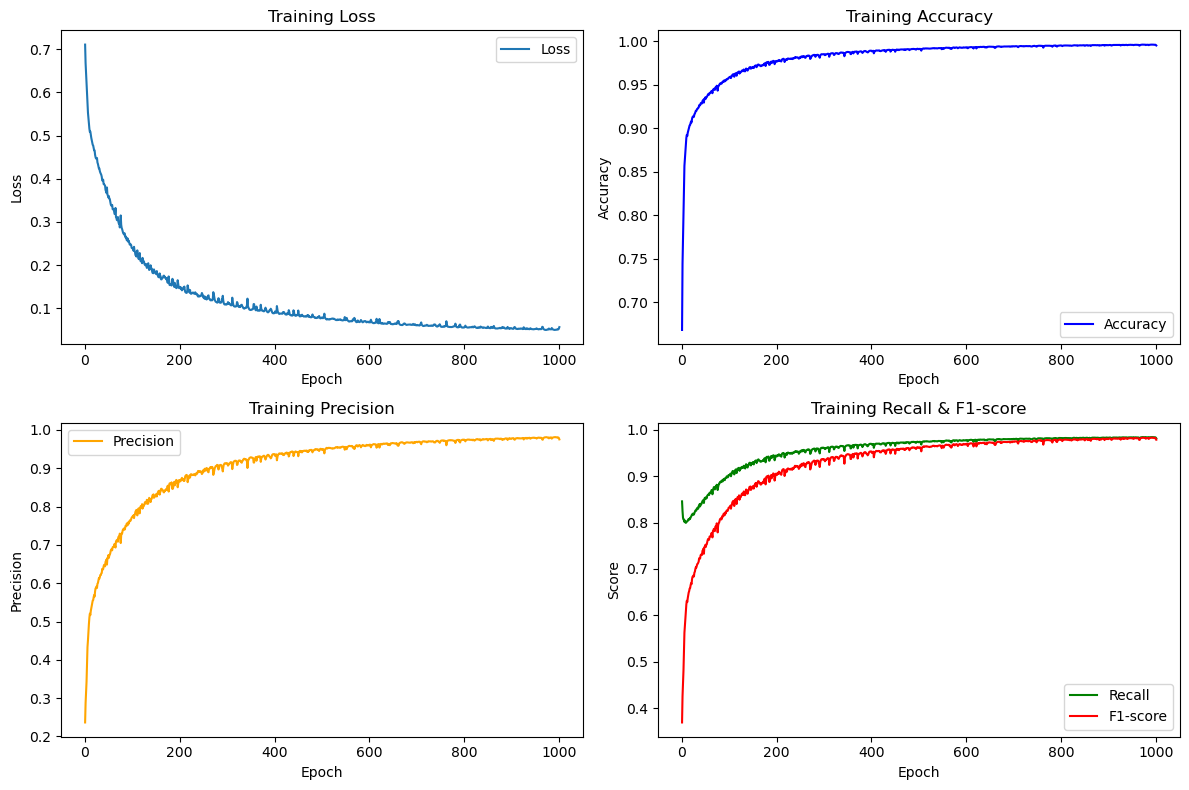

In [21]:
# 绘制曲线
plt.figure(figsize=(12, 8))

# 绘制 Loss 曲线
plt.subplot(2, 2, 1)
plt.plot(range(1, num_epochs + 1), losses, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(2, 2, 2)
plt.plot(range(1, num_epochs + 1), accuracies, label="Accuracy", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

# 绘制 Precision 曲线
plt.subplot(2, 2, 3)
plt.plot(range(1, num_epochs + 1), precisions, label="Precision", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training Precision")
plt.legend()

# 绘制 Recall 和 F1-score 曲线
plt.subplot(2, 2, 4)
plt.plot(range(1, num_epochs + 1), recalls, label="Recall", color="green")
plt.plot(range(1, num_epochs + 1), f1_scores, label="F1-score", color="red")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training Recall & F1-score")
plt.legend()

plt.tight_layout()
plt.show()

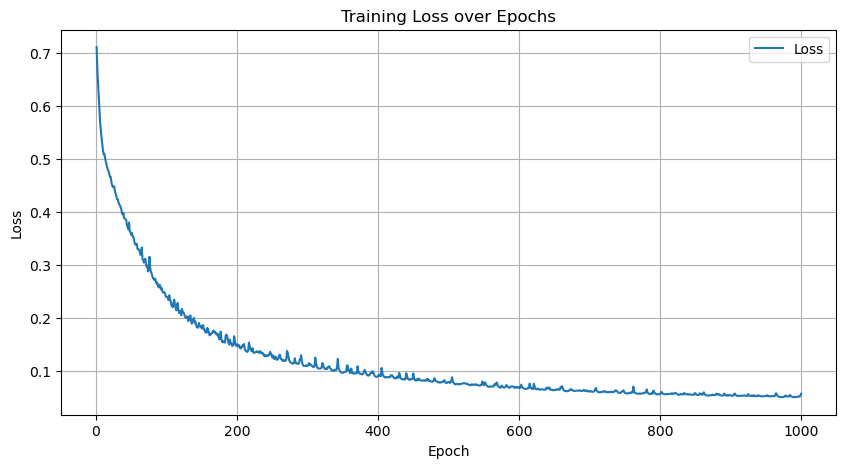

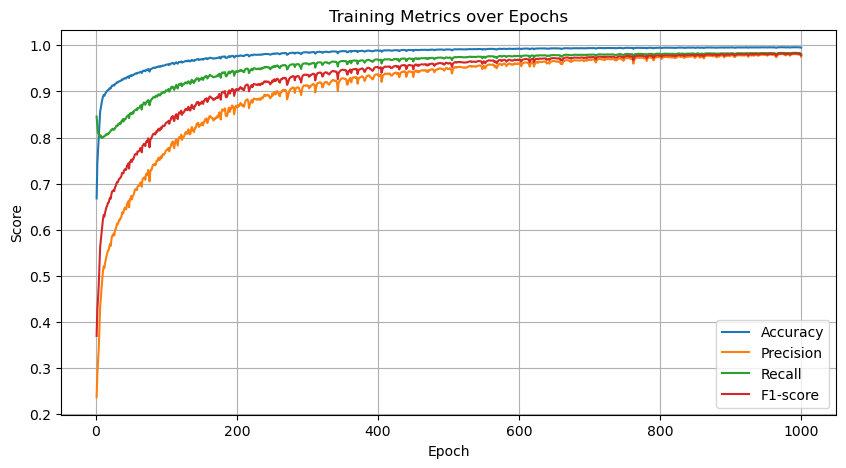

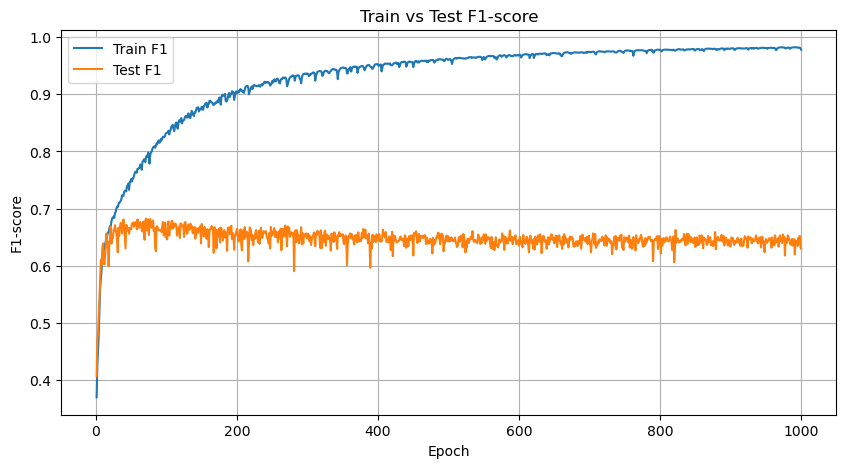

In [22]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(losses) + 1))

# 1. 学習曲線（Loss）
plt.figure(figsize=(10, 5))
plt.plot(epochs, losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 2. 評価指標の推移
plt.figure(figsize=(10, 5))
plt.plot(epochs, accuracies, label='Accuracy')
plt.plot(epochs, precisions, label='Precision')
plt.plot(epochs, recalls, label='Recall')
plt.plot(epochs, f1_scores, label='F1-score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training Metrics over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 3. Train vs Test F1-score
plt.figure(figsize=(10, 5))
plt.plot(epochs, f1_scores, label='Train F1')
plt.plot(epochs, test_f1_scores, label='Test F1')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.title('Train vs Test F1-score')
plt.legend()
plt.grid(True)
plt.show()

Checkpoint loaded!


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:07<00:00, 11.96it/s]


Recall: 0.6899
Precision: 0.6722
F1-score: 0.6810
[[42507357  1524189]
 [ 1404776  3125854]]


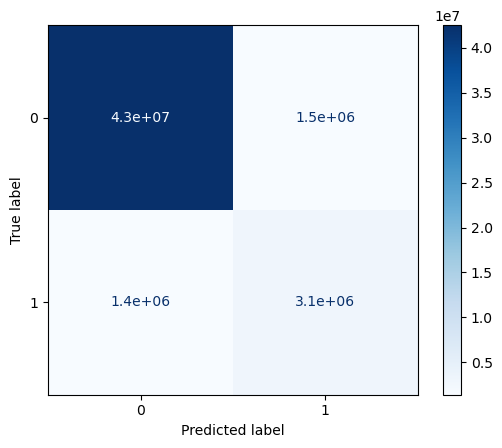

In [27]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# **学習の途中から再開**
save_path = weights_path(CONDITION)
if os.path.exists(save_path):
    checkpoint = torch.load(save_path, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"Checkpoint loaded!")

# 假设模型已经加载并设置为评估模式
model.eval()

# 存储路径
#model_save_path = "buf/kifuku_newdataver3_model.pth"
#torch.save(model.state_dict(), model_save_path)
#print(f"Model saved to {model_save_path}")

# 在测试数据上进行评估
all_preds = []
all_targets = []

# 遍历测试集
with torch.no_grad():  # 禁用梯度计算
    for (dem,air), masks in tqdm(test_loader, desc="Evaluating"):
        dem,air, masks = dem.to(device),air.to(device), masks.to(device)
        

        # Forward pass
        outputs = model(dem,air)

        # 将输出值转换为二值预测（0 或 1）
        preds = (torch.sigmoid(outputs) > 0.5).float()  # 二值化
        all_preds.append(preds.cpu())  # 将数据从 GPU 转移到 CPU
        all_targets.append(masks.cpu())  # 将目标从 GPU 转移到 CPU

# 拼接所有批次的预测和标签
all_preds = torch.cat(all_preds).numpy().flatten()  # 转换为 NumPy 数组并展平
all_targets = torch.cat(all_targets).numpy().flatten()  # 转换为 NumPy 数组并展平

# 确保预测和标签为整数类型
all_preds = all_preds.astype(int)
all_targets = all_targets.astype(int)


# 计算 Recall、Precision 和 F1-score
recall = recall_score(all_targets, all_preds, zero_division=0)
precision = precision_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)

# 打印评估指标
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

cm = confusion_matrix(all_targets, all_preds)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

Checkpoint loaded!


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:06<00:00, 13.68it/s]


Recall: 0.7158
Precision: 0.6789
F1-score: 0.6969
[[23908208   861945]
 [  723616  1822455]]


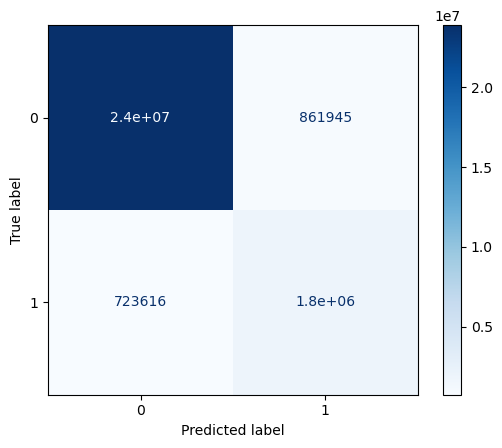

In [28]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# **学習の途中から再開**
save_path = weights_path(CONDITION)
if os.path.exists(save_path):
    checkpoint = torch.load(save_path, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"Checkpoint loaded!")

# 假设模型已经加载并设置为评估模式
model.eval()

# 存储路径
#model_save_path = "buf/kifuku_newdataver3_model.pth"
#torch.save(model.state_dict(), model_save_path)
#print(f"Model saved to {model_save_path}")

# 在测试数据上进行评估
all_preds = []
all_targets = []
crop = 16  # 除去する境界幅（px）
# 遍历测试集
with torch.no_grad():  # 禁用梯度计算
    for (dem,air), masks in tqdm(test_loader, desc="Evaluating"):
        dem,air, masks = dem.to(device),air.to(device), masks.to(device)
        

        # Forward pass
        outputs = model(dem,air)

        # 将输出值转换为二值预测（0 或 1）
        preds = (torch.sigmoid(outputs) > 0.5).float()  # 二值化
        # 境界16pxを除去して中心96x96のみ評価
        preds  = preds[:, :, crop:-crop, crop:-crop]
        masks  = masks[:, :, crop:-crop, crop:-crop]
        all_preds.append(preds.cpu())  # 将数据从 GPU 转移到 CPU
        all_targets.append(masks.cpu())  # 将目标从 GPU 转移到 CPU

# 拼接所有批次的预测和标签
all_preds = torch.cat(all_preds).numpy().flatten()  # 转换为 NumPy 数组并展平
all_targets = torch.cat(all_targets).numpy().flatten()  # 转换为 NumPy 数组并展平

# 确保预测和标签为整数类型
all_preds = all_preds.astype(int)
all_targets = all_targets.astype(int)


# 计算 Recall、Precision 和 F1-score
recall = recall_score(all_targets, all_preds, zero_division=0)
precision = precision_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)

# 打印评估指标
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

cm = confusion_matrix(all_targets, all_preds)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

Generating Predictions: 100%|██████████████████████████████████████████████████████████| 93/93 [00:07<00:00, 13.12it/s]


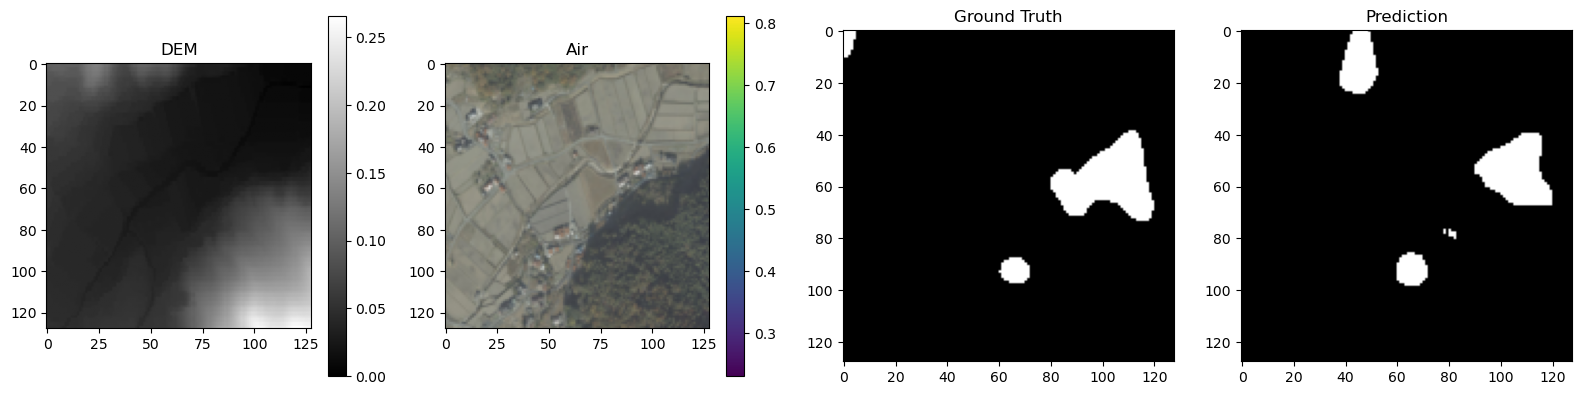

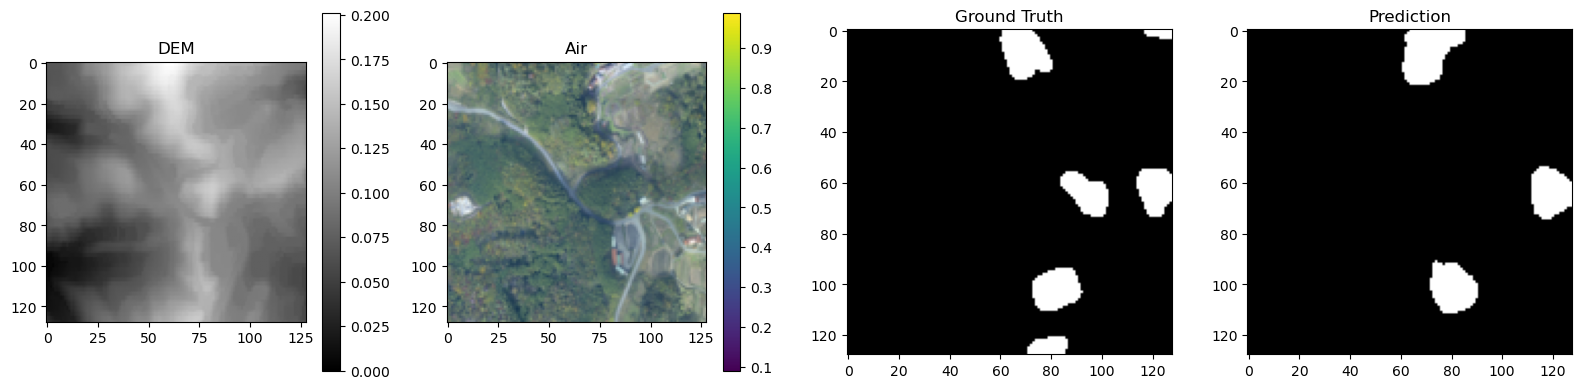

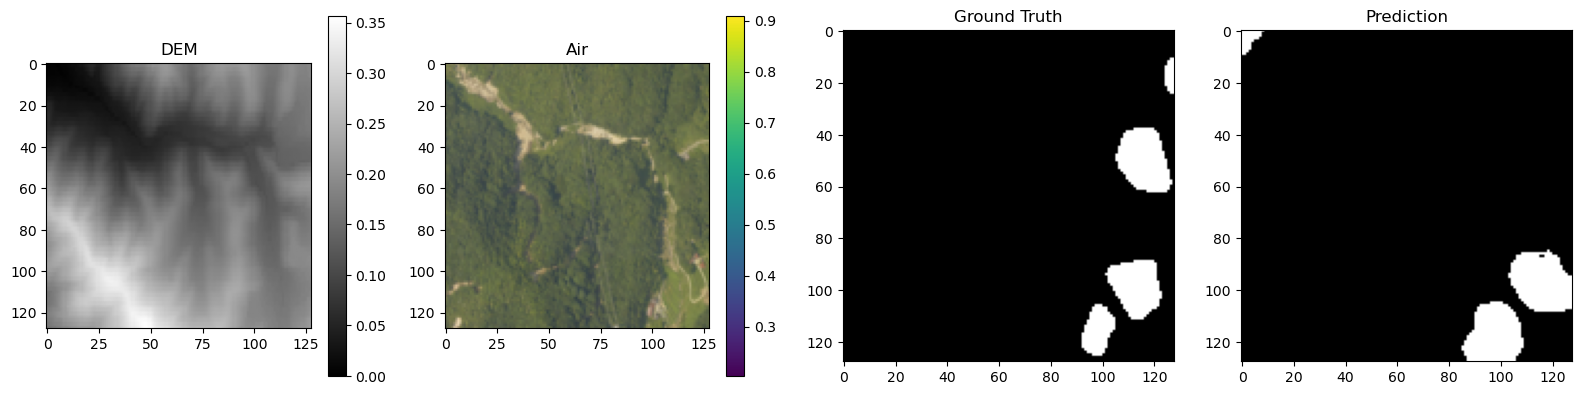

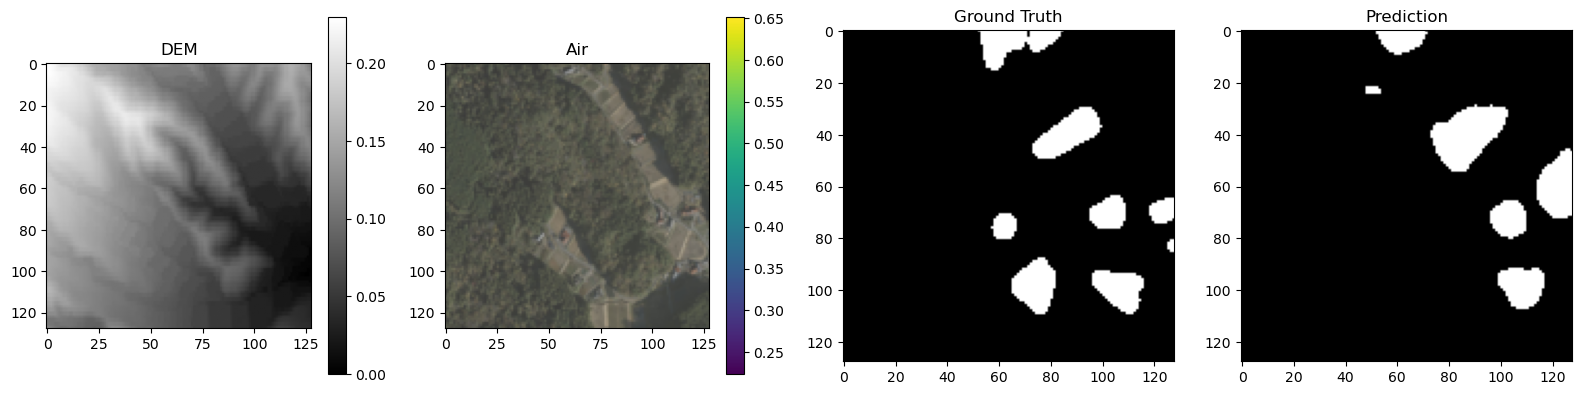

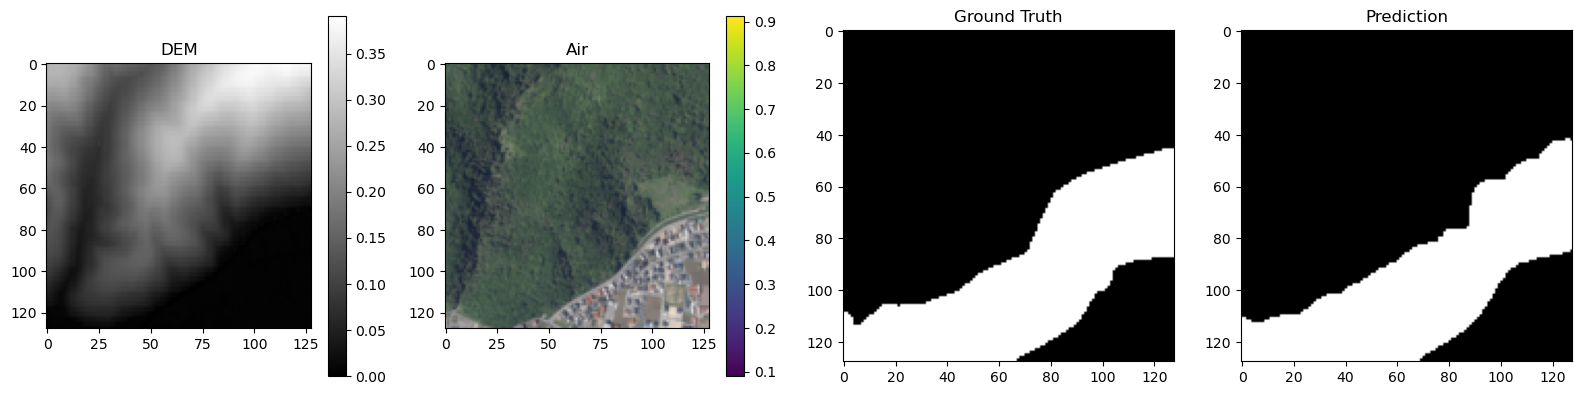

予測画像数: 2964


In [29]:
import os
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# 評価モード
model.eval()

predictions = []
dem_inputs = []
air_inputs = []
ground_truths = []

# 推論
with torch.no_grad():

    for (dem,air), masks in tqdm(
        test_loader,
        desc="Generating Predictions"
    ):

        #images = images.to(device)
        dem=dem.to(device)
        air=air.to(device)
        

        outputs = model(dem,air)

        preds = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        predictions.append(preds.cpu())
        dem_inputs.append(dem.cpu())
        air_inputs.append(air.cpu())
        ground_truths.append(masks.cpu())

# 結合
predictions = torch.cat(predictions).numpy()
dem_inputs = torch.cat(dem_inputs).numpy()
air_inputs = torch.cat(air_inputs).numpy()
ground_truths = torch.cat(ground_truths).numpy()

# 表示枚数
n_display = 5

for i in range(n_display):

    plt.figure(figsize=(16,4))

    # =====================
    # DEM
    # =====================
    plt.subplot(1,4,1)

    plt.title("DEM")

    plt.imshow(
        dem_inputs[i][0],
        cmap="gray"
    )

    plt.colorbar()

    # =====================
    # Fractal
    # =====================
    plt.subplot(1,4,2)

    plt.title("Air")

    plt.imshow(
        np.transpose(air_inputs[i],(1,2,0))
        
    )

    plt.colorbar()

    # =====================
    # Ground Truth
    # =====================
    plt.subplot(1,4,3)

    plt.title("Ground Truth")

    plt.imshow(
        ground_truths[i][0],
        cmap="gray"
    )

    # =====================
    # Prediction
    # =====================
    plt.subplot(1,4,4)

    plt.title("Prediction")

    plt.imshow(
        predictions[i][0],
        cmap="gray"
    )

    plt.tight_layout()

    plt.show()

print("予測画像数:", len(predictions))

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(curve_path(CONDITION))

epochs = df["Epoch"]

losses = df["Loss"]
accuracies = df["Accuracy"]
precisions = df["Precision"]
recalls = df["Recall"]
f1_scores = df["F1-score"]
test_f1_scores = df["Test-F1-score"]

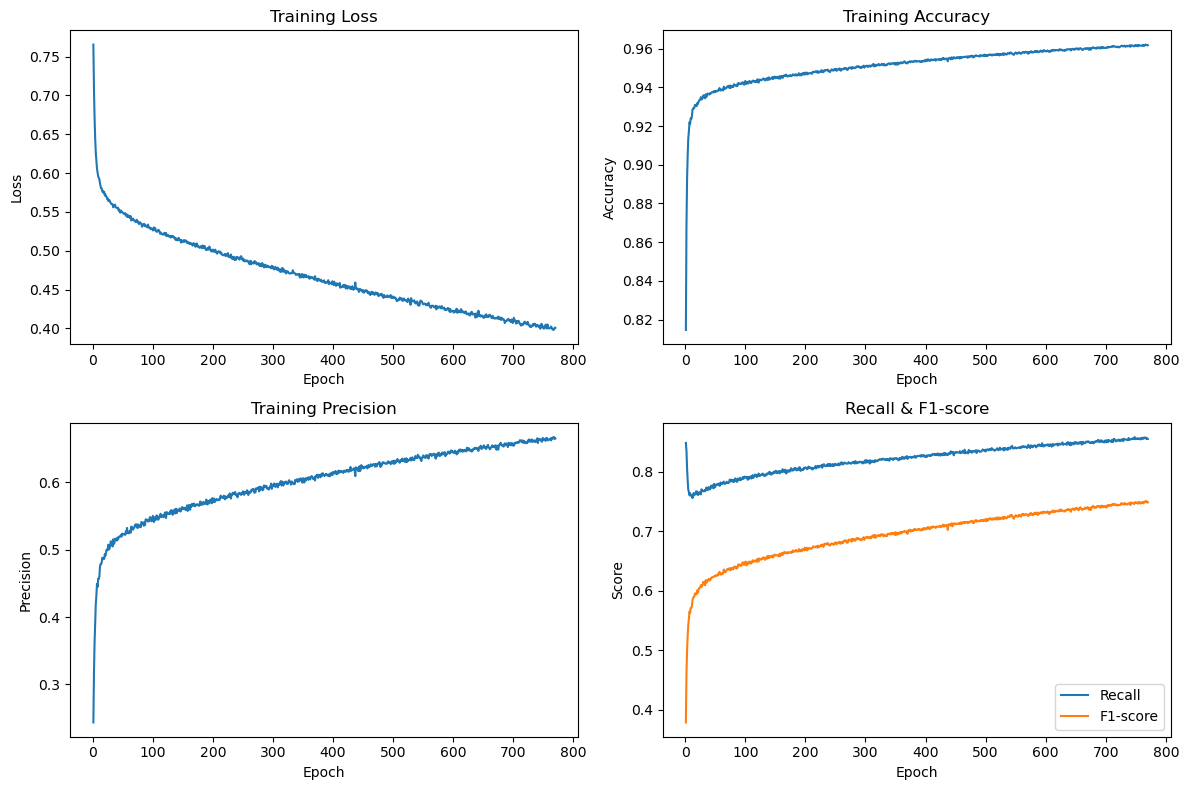

In [29]:
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.subplot(2,2,2)
plt.plot(epochs, accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.subplot(2,2,3)
plt.plot(epochs, precisions)
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training Precision")

plt.subplot(2,2,4)
plt.plot(epochs, recalls, label="Recall")
plt.plot(epochs, f1_scores, label="F1-score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Recall & F1-score")
plt.legend()

plt.tight_layout()
plt.show()

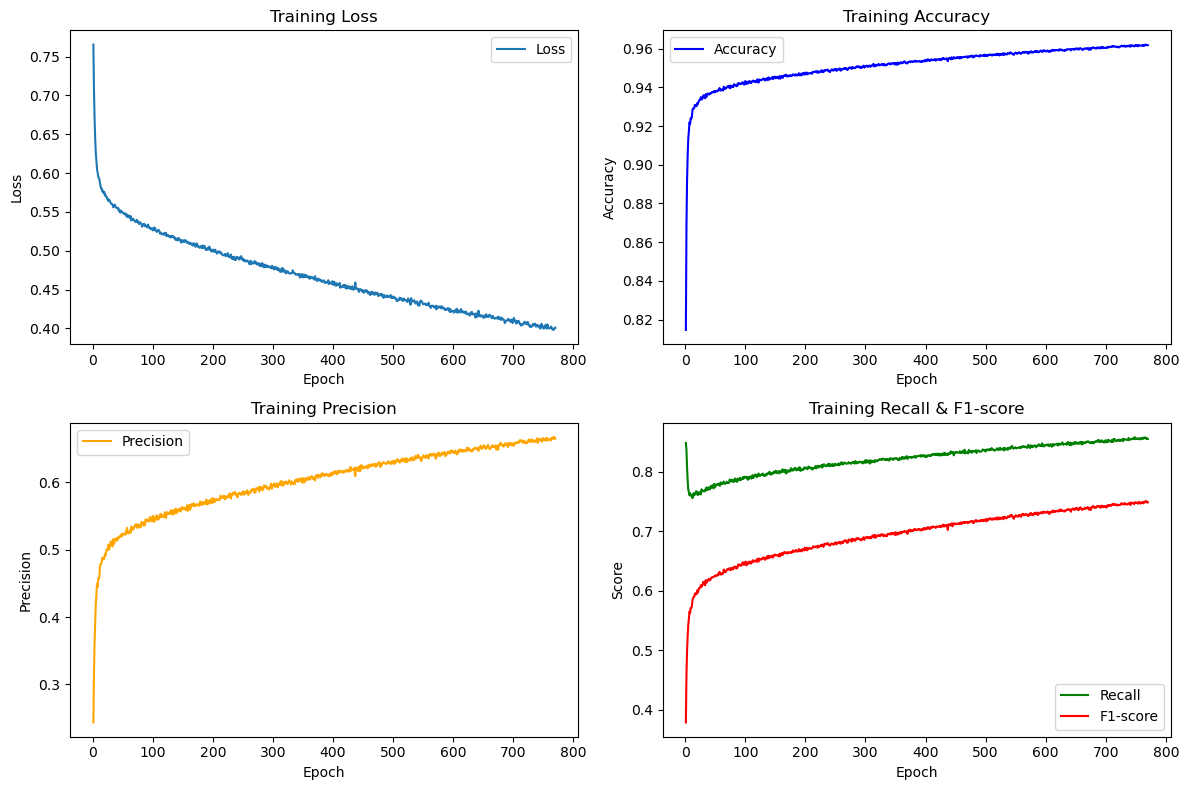

In [33]:
# 绘制曲线
plt.figure(figsize=(12, 8))

# 绘制 Loss 曲线
plt.subplot(2, 2, 1)
plt.plot(epochs, losses, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(2, 2, 2)
plt.plot(epochs, accuracies, label="Accuracy", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

# 绘制 Precision 曲线
plt.subplot(2, 2, 3)
plt.plot(epochs, precisions, label="Precision", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training Precision")
plt.legend()

# 绘制 Recall 和 F1-score 曲线
plt.subplot(2, 2, 4)
plt.plot(epochs, recalls, label="Recall", color="green")
plt.plot(epochs, f1_scores, label="F1-score", color="red")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training Recall & F1-score")
plt.legend()

plt.tight_layout()
plt.show()

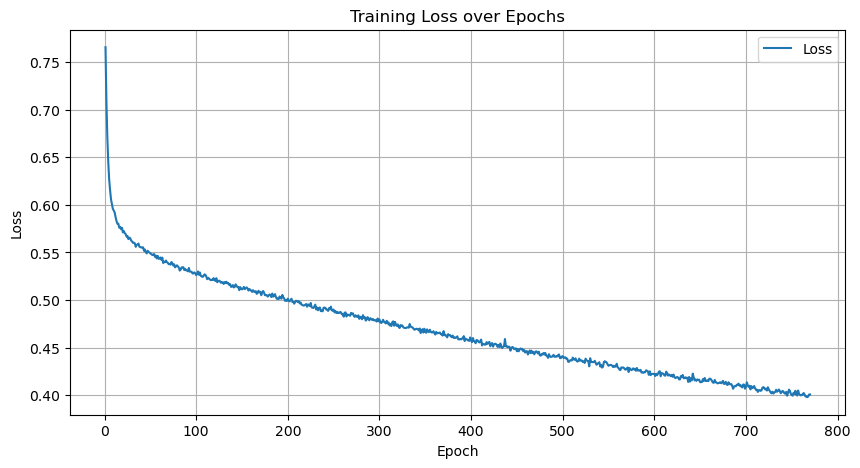

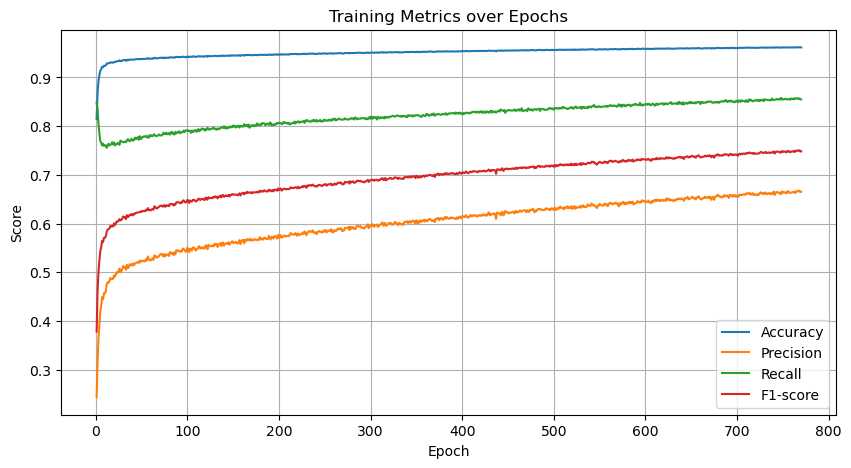

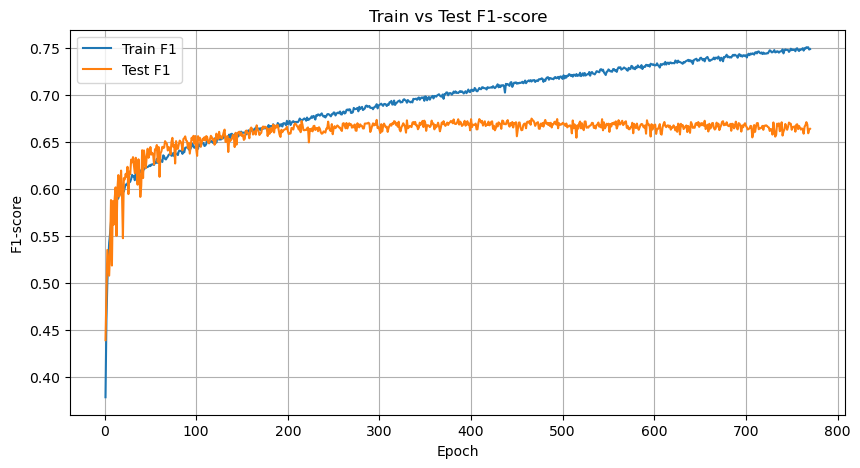

In [36]:
import matplotlib.pyplot as plt



# 1. 学習曲線（Loss）
plt.figure(figsize=(10, 5))
plt.plot(epochs, losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 2. 評価指標の推移
plt.figure(figsize=(10, 5))
plt.plot(epochs, accuracies, label='Accuracy')
plt.plot(epochs, precisions, label='Precision')
plt.plot(epochs, recalls, label='Recall')
plt.plot(epochs, f1_scores, label='F1-score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training Metrics over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 3. Train vs Test F1-score
plt.figure(figsize=(10, 5))
plt.plot(epochs, f1_scores, label='Train F1')
plt.plot(epochs, test_f1_scores, label='Test F1')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.title('Train vs Test F1-score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test, No_train, No_test, xh_train, xh_test, nh_train, nh_test = train_test_split(dataset3.DEM, dataset3.Mask, dataset3.No, dataset3.Max_H, dataset3.Min_H, test_size=0.2, random_state=42)

## 島根県データセットでの汎化性能評価（SAM+APM / DEM+APM 条件）

広島データで学習したマルチ入力（DEM/SAM + AirPhoto）モデルを、島根県のデータ
（`load_any_dataset`経由で読み込み）で評価する。学習データと異なり、警戒区域を
含まない背景タイルも除外せず全て評価対象に含める。
評価はTP/FP/FN/TNをバッチごとに積算する方式で行い、大きなタイル数でも
メモリを圧迫しないようにしている。

In [30]:
# ============================================================
# 1. 島根データの読み込み（SAM+APM または DEM+APM のpklを指定）
# ============================================================
shimane_path = dataset_path("Shimane", "shimane_dem_apm_normalized.pkl")  # 実際のファイルパスに変更してください
shimane_raw = load_dataset(shimane_path)
print(f"島根データ タイル数: {len(shimane_raw.No)}")
print(f"DEM[0] shape: {np.array(shimane_raw.DEM[0]).shape}")
print(f"AirPhoto[0] shape: {np.array(shimane_raw.AirPhoto[0]).shape}")

# 【正規化についての注意】
# このノートブックの学習側では、DEM(SAM)フィールドに特別な正規化を適用しておらず、
# pklに入っている値をそのまま使っている（AirPhotoのみモデル入力直前に/255.0で0-1化）。
# そのため、島根側もbuild_shimane_dataset_v5.pyで生成した生のSAM値（度単位）を
# そのまま使う想定。学習データ側でDEMに別の正規化を適用した場合は、
# ここでも同じ変換を島根データに適用すること。

島根データ タイル数: 24569
DEM[0] shape: (128, 128)
AirPhoto[0] shape: (128, 128, 3)


In [31]:
# ============================================================
# 2. マスクにガウシアンフィルターを適用（学習時と同じ前処理）
#    学習データと違い、警戒区域を含まないタイルも除外せず全て使う
#    メモリ節約のため、AirPhoto/Maskはuint8のまま保持する
# ============================================================
from scipy.ndimage import gaussian_filter
import gc

shimane_dem_list = []
shimane_air_list = []
shimane_mask_list = []
for i in range(len(shimane_raw.No)):
    dem_i = np.array(shimane_raw.DEM[i], dtype=np.float32)
    air_i = np.array(shimane_raw.AirPhoto[i], dtype=np.uint8)
    mask_i = np.array(shimane_raw.Mask[i]).astype(np.uint8) * 255
    mask_i = gaussian_filter(mask_i, sigma=1)
    mask_i = (mask_i > 0).astype(np.uint8)
    shimane_dem_list.append(dem_i)
    shimane_air_list.append(air_i)
    shimane_mask_list.append(mask_i)

del shimane_raw
gc.collect()
print(f"タイル数: {len(shimane_dem_list)}")

タイル数: 24569


In [32]:
# ============================================================
# 3. 配列変換・Tensor化
#    AirPhoto/Maskはuint8のまま保持し、float化はDualInputDatasetの
#    __getitem__内でサンプル単位に行う（学習側と同じ方式でメモリ節約）
# ============================================================
shimane_dem_arr = np.array(shimane_dem_list, dtype=np.float32)
shimane_air_arr = np.array(shimane_air_list, dtype=np.uint8)
shimane_mask_arr = np.array(shimane_mask_list, dtype=np.uint8)
del shimane_dem_list, shimane_air_list, shimane_mask_list
gc.collect()

shimane_dem_arr = np.expand_dims(shimane_dem_arr, axis=1)          # [N, 1, H, W]
shimane_air_arr = np.transpose(shimane_air_arr, (0, 3, 1, 2))       # [N, 3, H, W] uint8のまま
shimane_mask_arr = np.expand_dims(shimane_mask_arr, axis=1)        # [N, 1, H, W] uint8のまま

X_dem_shimane = torch.from_numpy(shimane_dem_arr)   # float32
X_air_shimane = torch.from_numpy(shimane_air_arr)   # uint8
y_shimane = torch.from_numpy(shimane_mask_arr)      # uint8

print("DEM shape :", X_dem_shimane.shape, X_dem_shimane.dtype)
print("AirPhoto shape :", X_air_shimane.shape, X_air_shimane.dtype)
print("Mask shape :", y_shimane.shape, y_shimane.dtype)

DEM shape : torch.Size([24569, 1, 128, 128]) torch.float32
AirPhoto shape : torch.Size([24569, 3, 128, 128]) torch.uint8
Mask shape : torch.Size([24569, 1, 128, 128]) torch.uint8


In [33]:
# ============================================================
# 4. DualInputDataset / DataLoader 作成
#    DualInputDatasetの__getitem__内でfloat化・正規化される
# ============================================================
shimane_dataset = DualInputDataset(
    X_dem_shimane,
    X_air_shimane,
    y_shimane
)
shimane_loader = DataLoader(
    shimane_dataset,
    batch_size=32,
    shuffle=False
)

for (dem, air), masks in shimane_loader:
    print("DEM:", dem.shape, dem.dtype, " AirPhoto:", air.shape, air.dtype, " Mask:", masks.shape, masks.dtype)
    break

DEM: torch.Size([32, 1, 128, 128]) torch.float32  AirPhoto: torch.Size([32, 3, 128, 128]) torch.float32  Mask: torch.Size([32, 1, 128, 128]) torch.float32


Evaluating on Shimane (full): 100%|██████████████████████████████████████████████████| 768/768 [00:53<00:00, 14.23it/s]

[島根/面積評価] Recall: 0.5144
[島根/面積評価] Precision: 0.5681
[島根/面積評価] F1-score: 0.5399
[[382496250   5633608]
 [  6997092   7411546]]


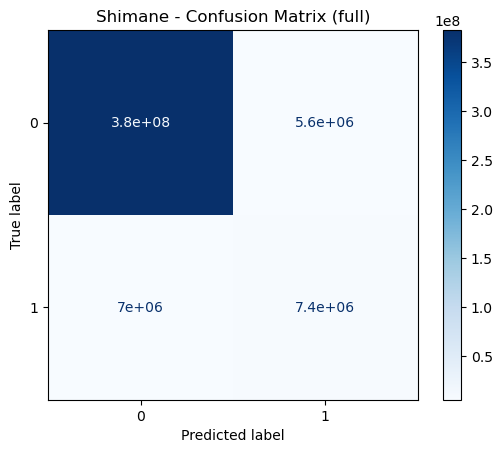

In [34]:
# ============================================================
# 5. 面積評価（全128x128）
#    TP/FP/FN/TNをバッチごとに積算する方式（巨大配列を作らない）
# ============================================================
model.eval()

tp_a = fp_a = fn_a = tn_a = 0

with torch.no_grad():
    for (dem, air), masks in tqdm(shimane_loader, desc="Evaluating on Shimane (full)"):
        dem, air, masks = dem.to(device), air.to(device), masks.to(device)
        outputs = model(dem, air)
        preds_bin = (torch.sigmoid(outputs) > 0.5)
        targets_bin = (masks > 0.5)

        tp_a += ((preds_bin) & (targets_bin)).sum().item()
        fp_a += ((preds_bin) & (~targets_bin)).sum().item()
        fn_a += ((~preds_bin) & (targets_bin)).sum().item()
        tn_a += ((~preds_bin) & (~targets_bin)).sum().item()

shimane_precision = tp_a / (tp_a + fp_a) if (tp_a + fp_a) > 0 else 0.0
shimane_recall = tp_a / (tp_a + fn_a) if (tp_a + fn_a) > 0 else 0.0
shimane_f1 = (2 * tp_a) / (2 * tp_a + fp_a + fn_a) if (2 * tp_a + fp_a + fn_a) > 0 else 0.0

print(f"[島根/面積評価] Recall: {shimane_recall:.4f}")
print(f"[島根/面積評価] Precision: {shimane_precision:.4f}")
print(f"[島根/面積評価] F1-score: {shimane_f1:.4f}")

shimane_cm = np.array([[tn_a, fp_a], [fn_a, tp_a]])
print(shimane_cm)
disp = ConfusionMatrixDisplay(confusion_matrix=shimane_cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Shimane - Confusion Matrix (full)")
plt.show()

Evaluating on Shimane (border-cropped): 100%|████████████████████████████████████████| 768/768 [00:54<00:00, 14.02it/s]

[島根/境界評価] Recall: 0.5367
[島根/境界評価] Precision: 0.5975
[島根/境界評価] F1-score: 0.5655
[[215261450   2964919]
 [  3799458   4402077]]


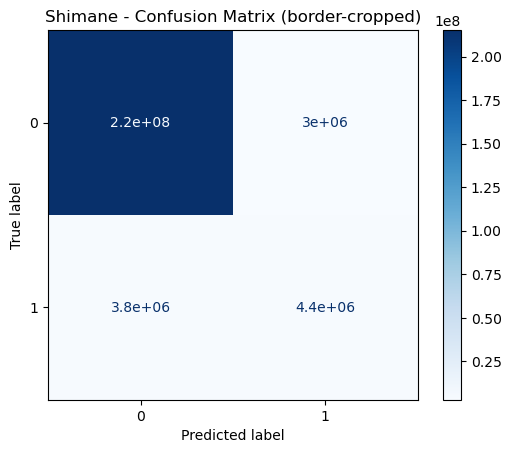

In [35]:
# ============================================================
# 6. 境界評価（境界16pxを除去し中心96x96のみ）
#    こちらもTP/FP/FN/TNの積算方式
# ============================================================
model.eval()

tp_b = fp_b = fn_b = tn_b = 0
crop = 16

with torch.no_grad():
    for (dem, air), masks in tqdm(shimane_loader, desc="Evaluating on Shimane (border-cropped)"):
        dem, air, masks = dem.to(device), air.to(device), masks.to(device)
        outputs = model(dem, air)
        preds_bin = (torch.sigmoid(outputs) > 0.5)
        targets_bin = (masks > 0.5)

        preds_bin = preds_bin[:, :, crop:-crop, crop:-crop]
        targets_bin = targets_bin[:, :, crop:-crop, crop:-crop]

        tp_b += ((preds_bin) & (targets_bin)).sum().item()
        fp_b += ((preds_bin) & (~targets_bin)).sum().item()
        fn_b += ((~preds_bin) & (targets_bin)).sum().item()
        tn_b += ((~preds_bin) & (~targets_bin)).sum().item()

shimane_precision_b = tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else 0.0
shimane_recall_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0.0
shimane_f1_b = (2 * tp_b) / (2 * tp_b + fp_b + fn_b) if (2 * tp_b + fp_b + fn_b) > 0 else 0.0

print(f"[島根/境界評価] Recall: {shimane_recall_b:.4f}")
print(f"[島根/境界評価] Precision: {shimane_precision_b:.4f}")
print(f"[島根/境界評価] F1-score: {shimane_f1_b:.4f}")

shimane_cm_b = np.array([[tn_b, fp_b], [fn_b, tp_b]])
print(shimane_cm_b)
disp = ConfusionMatrixDisplay(confusion_matrix=shimane_cm_b)
disp.plot(cmap=plt.cm.Blues)
plt.title("Shimane - Confusion Matrix (border-cropped)")
plt.show()

In [ ]:
# ============================================================
# 7. 予測結果の目視確認（少数サンプルのみ抽出して表示、メモリ節約のため
#    全件をtorch.catせず、先頭1バッチだけ使う）
# ============================================================
model.eval()

n_display = 5
with torch.no_grad():
    for (dem, air), masks in shimane_loader:
        dem_d = dem.to(device)
        air_d = air.to(device)
        outputs = model(dem_d, air_d)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        dem_np = dem.numpy()
        air_np = air.numpy()
        masks_np = masks.numpy()
        break  # 最初のバッチだけで十分

for i in range(min(n_display, dem_np.shape[0])):
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.title("DEM/SAM")
    plt.imshow(dem_np[i][0], cmap="gray")
    plt.colorbar()

    plt.subplot(1, 4, 2)
    plt.title("AirPhoto")
    plt.imshow(np.transpose(air_np[i], (1, 2, 0)))

    plt.subplot(1, 4, 3)
    plt.title("Ground Truth")
    plt.imshow(masks_np[i][0], cmap="gray")

    plt.subplot(1, 4, 4)
    plt.title("Prediction")
    plt.imshow(preds[i][0], cmap="gray")

    plt.tight_layout()
    plt.show()